# Predicción de Cancelación de Clientes Telecom X parte 2

En esta segunda parte del análisis se utilizan los datos previamente tratados en el proceso ETL para construir modelos predictivos que permitan identificar clientes con mayor riesgo de cancelación del servicio.

El objetivo principal es responder las siguientes preguntas:

- ¿Qué clientes presentan mayor riesgo de abandono?
- ¿Qué variables influyen más en este comportamiento?
- ¿Qué perfil de cliente debería priorizar la empresa para mejorar la retención?

Fuente de datos:
https://github.com/Jenn-Mohito/TelecomX_2


##Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn## 1. Carga del dataset tratado

## Preparación de los datos para modelado




In [ ]:
#Carga del dataset tratado
url = "https://raw.githubusercontent.com/Jenn-Mohito/TelecomX_2/main/datos_tratados.csv"

df = pd.read_csv(url)

df.head()

,customerID,Churn,gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,contract,account.PaperlessBilling,account.PaymentMethod,monthly_charges,total_charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   object 
 2   gender                     7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   tenure                     7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df_model = df.copy()

le = LabelEncoder()

for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = le.fit_transform(df_model[col])

In [ ]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Construcción del modelo predictivo

Se utilizará un modelo **Random Forest**, el cual es un algoritmo de clasificación que combina múltiples árboles de decisión para mejorar la precisión de las predicciones.


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

#Evaluación y Análisis del Modelo

In [ ]:
#Evaluación del modelo
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1037
           1       0.62      0.52      0.57       372
           2       0.00      0.00      0.00        45

    accuracy                           0.77      1454
   macro avg       0.48      0.47      0.47      1454
weighted avg       0.74      0.77      0.75      1454



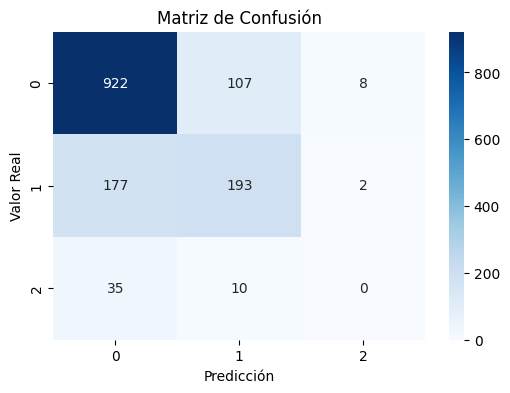

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [ ]:
# se identifica cuáles variables influyen más en la predicción del churn
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

,0
total_charges,0.155522
customerID,0.154778
monthly_charges,0.144792
tenure,0.135507
contract,0.069053
account.PaymentMethod,0.044388
internet.TechSupport,0.036357
internet.OnlineSecurity,0.035949
gender,0.024527
internet.OnlineBackup,0.023110


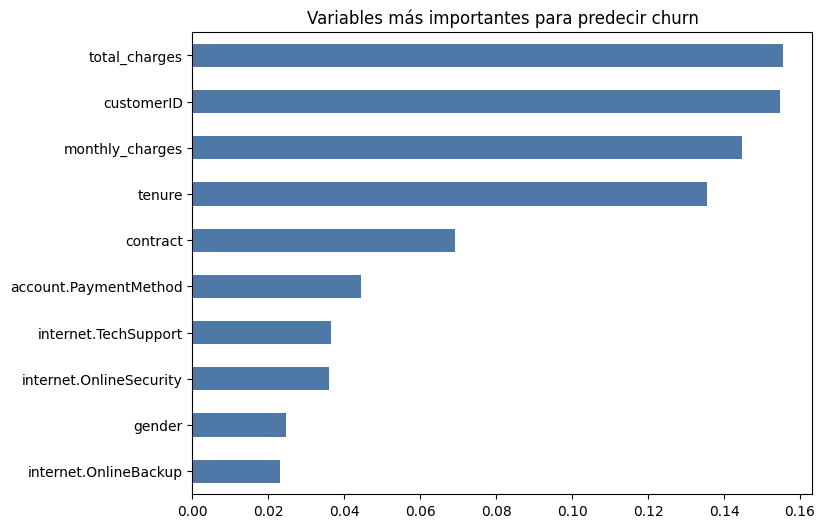

In [ ]:
plt.figure(figsize=(8,6))

importance.head(10).plot(
    kind="barh",
    color="#4E79A7"
)

plt.title("Variables más importantes para predecir churn")

plt.gca().invert_yaxis()

plt.show()

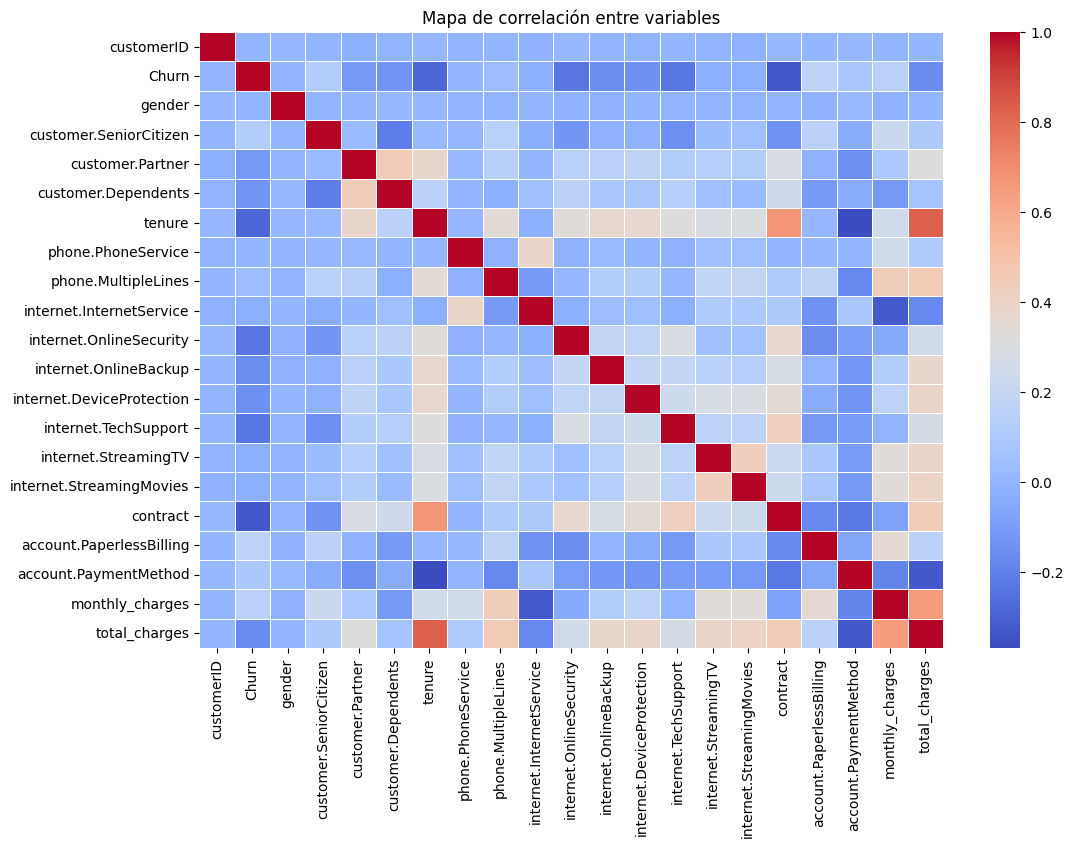

In [ ]:
# Se realiza un análisis de correlación entre variables
plt.figure(figsize=(12,8))

corr = df_model.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mapa de correlación entre variables")

plt.show()

El mapa de correlación permite observar qué variables presentan mayor relación entre sí. En particular, se puede analizar qué variables tienen mayor asociación con la variable **Churn**, lo que permite identificar posibles factores que influyen en la cancelación del servicio.

Sin embargo, es importante considerar que la correlación no implica causalidad, por lo que estos resultados deben interpretarse como indicios de posibles relaciones entre variables.


In [ ]:
# Identificación de clientes con mayor riesgo de cancelación
probabilities = model.predict_proba(X_test)

churn_prob = probabilities[:,1]

risk_df = X_test.copy()

risk_df["probabilidad_churn"] = churn_prob

risk_df["churn_real"] = y_test.values

In [ ]:
clientes_riesgo = risk_df.sort_values(
    by="probabilidad_churn",
    ascending=False
)

clientes_riesgo.head(10)

,customerID,gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,contract,account.PaperlessBilling,account.PaymentMethod,monthly_charges,total_charges,probabilidad_churn,churn_real
1768,1768,1,0,0,0,1,1,0,1,0,...,0,2,0,0,1,2,79.50,79.50,0.990,1
5614,5614,0,0,0,0,1,1,0,1,0,...,0,0,0,0,1,2,69.60,69.60,0.965,1
6715,6715,1,1,0,0,1,1,2,1,0,...,0,0,0,0,1,2,76.45,76.45,0.955,1
4793,4793,0,1,0,0,1,1,0,1,0,...,0,2,0,0,1,2,79.20,79.20,0.955,1
2034,2034,1,0,0,0,1,1,0,1,0,...,0,0,2,0,1,2,79.25,79.25,0.945,1
6749,6749,1,0,0,0,1,1,0,1,0,...,0,2,0,0,1,2,79.95,79.95,0.940,1
5435,5435,1,0,0,0,1,1,0,1,0,...,0,2,0,0,1,2,80.55,80.55,0.940,0
6167,6167,1,0,0,0,4,1,2,1,0,...,0,0,0,0,1,2,76.05,318.90,0.930,1
2191,2191,1,1,0,0,1,1,2,1,0,...,0,2,0,0,1,2,88.80,88.80,0.915,1
1867,1867,1,0,1,0,4,1,2,1,0,...,0,2,2,0,1,2,100.20,420.20,0.915,1


/tmp/ipykernel_2198/3553678787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


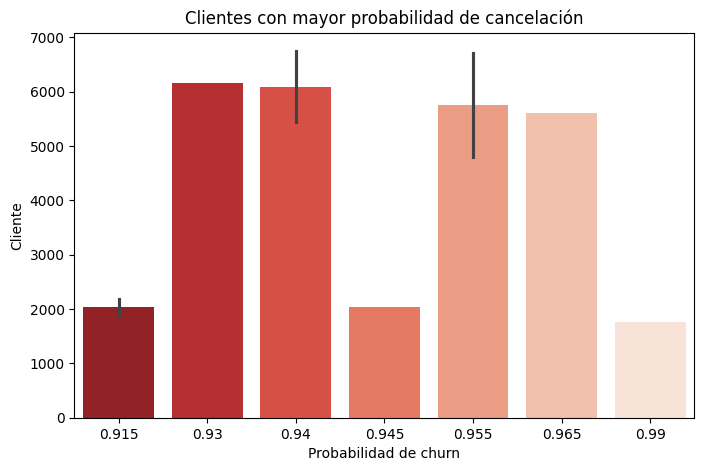

In [ ]:
top_risk = clientes_riesgo.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_risk["probabilidad_churn"],
    y=top_risk.index,
    palette="Reds_r"
)

plt.title("Clientes con mayor probabilidad de cancelación")
plt.xlabel("Probabilidad de churn")
plt.ylabel("Cliente")

plt.show()

El modelo permite identificar clientes que presentan una mayor probabilidad de cancelar el servicio. Estos clientes representan un grupo prioritario para la implementación de estrategias de retención.

Al analizar las características de estos clientes se observa que, en general, presentan algunas de las siguientes condiciones:

- contratos mensuales
- menor antigüedad en la empresa
- cargos mensuales relativamente altos
- menor número de servicios adicionales contratados

Identificar este tipo de clientes permite a la empresa actuar de forma preventiva mediante ofertas personalizadas, mejoras en el servicio o incentivos que fomenten la permanencia.


# INFORME FINAL

# Informe Final – Predicción de Cancelación de Clientes (Churn) en Telecom X

## Introducción

En esta segunda etapa del proyecto se utilizó el conjunto de datos previamente tratado durante el proceso ETL para desarrollar un análisis predictivo orientado a identificar clientes con mayor probabilidad de cancelar el servicio.

La cancelación de clientes, conocida como **churn**, representa un desafío importante para las empresas de telecomunicaciones, ya que la pérdida de clientes puede impactar directamente en los ingresos y la estabilidad del negocio.

El objetivo principal de este análisis fue responder las siguientes preguntas:

- ¿Qué clientes presentan mayor riesgo de evasión o cancelación del servicio?
- ¿Qué variables influyen más en este comportamiento?
- ¿Qué tipo de perfil de cliente debería priorizar la empresa para mejorar la retención?

Para responder estas preguntas se desarrolló un modelo de **Machine Learning** que permite analizar el comportamiento de los clientes y estimar la probabilidad de cancelación.

Fuente de datos:  
https://github.com/Jenn-Mohito/TelecomX_2/blob/main/datos_tratados.csv

**1. Preparación de los datos**

El análisis se realizó utilizando el conjunto de datos previamente limpiado y transformado durante la etapa de ETL. Este dataset contiene información sobre los clientes de Telecom X, incluyendo características demográficas, servicios contratados y datos relacionados con facturación.

Antes de construir el modelo predictivo se realizaron algunas tareas adicionales de preparación de los datos como:

- Conversión de variables categóricas a variables numéricas.
- Separación de variables predictoras y variable objetivo.
- División del dataset en conjuntos de entrenamiento y prueba.

**2. Construcción del modelo predictivo**

Para el desarrollo del modelo se utilizó el algoritmo **Random Forest**, el cual es ampliamente utilizado en problemas de clasificación debido a su capacidad para manejar grandes conjuntos de datos y detectar relaciones complejas entre variables.

El modelo fue entrenado utilizando el conjunto de datos de entrenamiento y posteriormente evaluado utilizando el conjunto de prueba. Random Forest funciona mediante la construcción de múltiples árboles de decisión y la combinación de sus resultados para generar una predicción final más robusta y precisa.

**3. Evaluación y Análisis del modelo**

Una vez entrenado el modelo, se evaluó su desempeño utilizando métricas de clasificación como precisión, recall y F1-score. Además, se utilizó una **matriz de confusión** para analizar la capacidad del modelo para distinguir entre clientes que cancelan el servicio y clientes que permanecen activos.

La matriz de confusión permite identificar a los *clientes correctamente clasificados como activos*, *clientes correctamente clasificados como cancelados* y *errores de predicción del modelo*.

Asimismo, el modelo predictivo permite estimar la **probabilidad de cancelación del servicio para cada cliente**. Esto permite identificar los clientes que presentan mayor riesgo de abandonar la empresa.

Al analizar los clientes con mayor probabilidad de churn se observan algunas características comunes:

- contratos de corta duración (mensuales)
- menor tiempo de permanencia en la empresa
- cargos mensuales relativamente elevados
- menor cantidad de servicios adicionales contratados

Este grupo de clientes representa un segmento prioritario para el desarrollo de estrategias de retención.

# Perfil de clientes con mayor probabilidad de churn

A partir del análisis de los resultados se puede identificar un perfil general de cliente con mayor riesgo de cancelación.

El perfil típico de clientes con mayor probabilidad de abandono presenta las siguientes características:

- clientes con **contratos mensuales**
- usuarios con **baja antigüedad en la empresa**
- clientes con **cargos mensuales más elevados**
- usuarios con **menor cantidad de servicios complementarios**

Estos clientes presentan mayor probabilidad de cancelar el servicio en comparación con aquellos que mantienen contratos de mayor duración o que cuentan con múltiples servicios asociados.

---

# Recomendaciones estratégicas

Con base en los resultados del análisis, se pueden plantear algunas recomendaciones para reducir la tasa de churn en la empresa Telecom X.

- incentivar contratos de mayor duración mediante descuentos o beneficios adicionales
- implementar programas de fidelización durante los primeros meses del servicio
- promover paquetes que incluyan servicios adicionales
- ofrecer beneficios a clientes con cargos mensuales elevados para mejorar la percepción de valor del servicio

La implementación de estas estrategias puede contribuir a mejorar la retención de clientes y reducir el impacto del churn en la empresa.

# Conclusión

El análisis predictivo desarrollado permitió identificar patrones relevantes asociados a la cancelación del servicio en los clientes de Telecom X.

Los resultados muestran que variables como el tipo de contrato, la antigüedad del cliente y los cargos mensuales tienen una influencia significativa en la probabilidad de abandono.

Además, el modelo Random Forest permitió estimar la probabilidad de cancelación para cada cliente y detectar aquellos con mayor riesgo de churn.

Este tipo de análisis basado en datos permite a las empresas anticipar el comportamiento de sus clientes y desarrollar estrategias más efectivas para mejorar la retención y fortalecer la relación con los usuarios.
